<a href="https://colab.research.google.com/github/SLIIT-SE-Evenza/AIML-Project-NASDAQ-Stock-Price-Trend-Predictor/blob/main/NASDAQ_CAT_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries

In [1]:
# Used for importing dataset from Kaggle
import kagglehub

# Used for getting the files and creating the full paths
import os

# Data Manipulation Tools
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Data Visualization Tools
import seaborn as sns
import matplotlib.pyplot as plt

# Will display the plot below the code
%matplotlib inline

sns.set(color_codes = True)

# Importing the dataset from Kaggle

In [2]:
# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path)

100%|██████████| 522M/522M [00:07<00:00, 71.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2


##### Listing the files that are in the dataset folder

In [3]:
# List files in the download directory
print("Files in the dataset directory:")
for file in os.listdir(path):
  print(file)

Files in the dataset directory:
stocks
etfs
symbols_valid_meta.csv


## Loading & Displaying the `CAT.csv` file

In [4]:
cat_file = os.path.join(path, 'stocks', 'CAT.csv')
df = pd.read_csv(cat_file)

# Displaying the first 5 rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,1.604167,1.619792,1.588542,1.604167,0.136957,163200.0
1,1962-01-03,1.604167,1.619792,1.588542,1.619792,0.138291,156000.0
2,1962-01-04,1.656250,1.708333,1.656250,1.661458,0.141849,355200.0
3,1962-01-05,1.661458,1.697917,1.656250,1.677083,0.143183,163200.0
4,1962-01-08,1.677083,1.703125,1.666667,1.687500,0.144072,204000.0


## Check for the Types of the Data in the Dataset

In [5]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64


Here, there are no categorical columns. All are numerical columns only. So, no encoding is required.

## Date Handling

In [38]:
#Convert Date and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Updated data types:")
print(df.dtypes)
print("\nFirst date:", df['Date'].min())
print("Last date:", df['Date'].max())

Updated data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Adj Close           float64
Volume              float64
dtype: object

First date: 1962-01-02 00:00:00
Last date: 2020-04-01 00:00:00


## Remove the irrelevant columns

In [6]:
df = df.drop(['Close'], axis=1)
df.head(5)

,Date,Open,High,Low,Adj Close,Volume
0,1962-01-02,1.604167,1.619792,1.588542,0.136957,163200.0
1,1962-01-03,1.604167,1.619792,1.588542,0.138291,156000.0
2,1962-01-04,1.656250,1.708333,1.656250,0.141849,355200.0
3,1962-01-05,1.661458,1.697917,1.656250,0.143183,163200.0
4,1962-01-08,1.677083,1.703125,1.666667,0.144072,204000.0


Display column names

In [7]:
print(list(df.columns))

['Date', 'Open', 'High', 'Low', 'Adj Close', 'Volume']


## Check for Duplicate Rows

In [9]:
df.shape    # Checks the dimension of the DataFrame

(14665, 6)

In [10]:
df.count()  # Counts the number of rows

,0
Date,14665
Open,14663
High,14663
Low,14663
Adj Close,14663
Volume,14663


`df.duplicated()`

This returns a **Boolean Series (True/False)** indicating whether each row in the DataFrame is a duplicate of a previous row.

`df[df.duplicated()]`

This filters the DataFrame and returns only the rows that are duplicates (excluding the first instance).

`duplicate_rows_df.shape`

This returns the shape of the new DataFrame (**number of duplicate rows**, **number of columns**).

In [11]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 6)


In [28]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


## Handling Missing or Null Values

In [12]:
print(df.isnull().sum())    # Determines the number of missing values in the dataset

Date         0
Open         2
High         2
Low          2
Adj Close    2
Volume       2
dtype: int64


### Forward Filling Approach and its analogy

Replacing missing stock values with a static 0 or the overall dataset average is technically executable in Python, but both methods are highly detrimental to financial time-series modeling.

#### Disadvantages of Filling with Zero

* **Artificial Crashes:** A stock price of $0 fundamentally dictates that the asset is entirely worthless. Inserting a 0 creates an immediate, catastrophic 100% price drop in your dataset.
* **Distorted Volatility:** Your machine learning algorithm will attempt to learn from this synthetic crash, which will severely skew technical indicators and any momentum features you calculate later, such as Daily Returns.

#### Disadvantages of Filling with the Average (Mean)

* **Trend Destruction:** Financial data is strictly chronological. If a stock averages \$50 over a five-year period, inserting that \$50 into a missing day during a bull market where the stock was trading at \$150 creates an artificial \$100 plunge.
* **Data Leakage:** Calculating a mean requires aggregating the entire dataset. If you use future prices to calculate an average to fill a past gap, you leak future information into the past, entirely invalidating the model's predictive integrity.

#### The Preferred Time-Series Approach

* **Logical Continuity:** Missing data in stock datasets is typically caused by market holidays or weekends. During these closures, the actual holding value of your investment does not change; the most logical "current value" is simply the previous day's closing price.

* **Forward-Filling:** This is exactly why the `.ffill()` method is standard practice for this project, as it carries the last known market price forward and preserves the continuous time-series sequence without inventing illogical price swings.

In [13]:
# Forward-fill missing data (carry the last known price forward)
df.ffill(inplace=True)

In [21]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Adj Close    0
Volume       0
dtype: int64


In [27]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


## Outliers Detection
- An outlier is a **data point that significantly differs from other observations in the dataset**.
- These values can be either unusually high or low compared to the rest of the data.
- Detecting and removing outliers is an important step in data preprocessing, as they can negatively impact the accuracy and performance of machine learning models.
---
- In this analysis, **Interquartile Range (IQR)** method is used to identify and remove outliers.
- The IQR technique is a reliable and commonly used approach that identifies values lying far outside the middle range of the data.
---
- Outliers can also be visually identified using **box plots**.
- In each plot, the points that appear outside the whiskers of the box represent potential outliers.
- By detecting and addressing these outliers, we aim to improve the quality and reliability of the dataset before proceeding to the modeling stage.

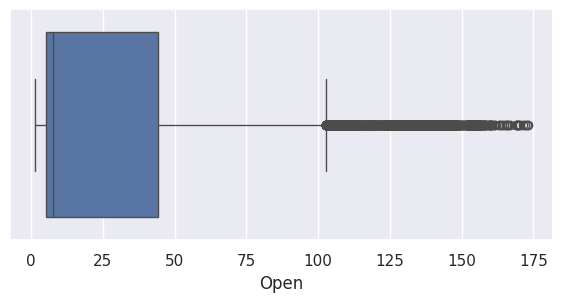

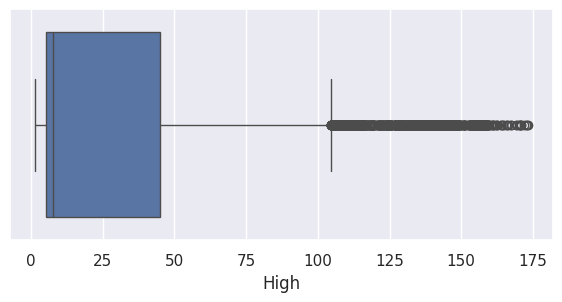

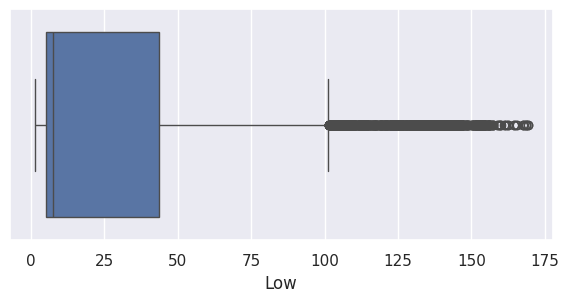

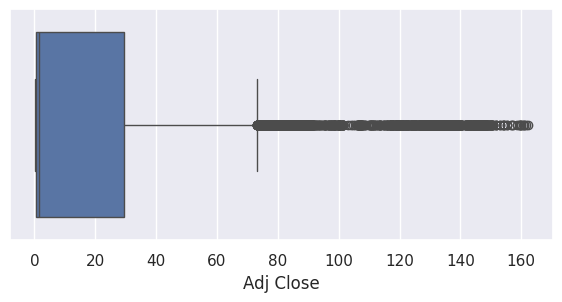

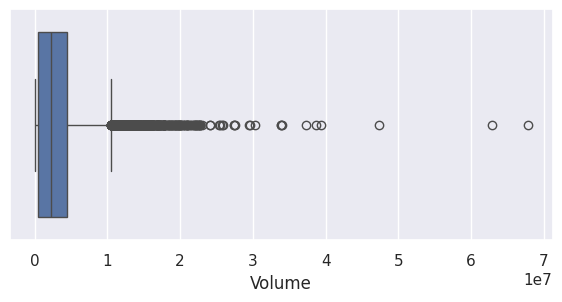

In [22]:
numeric_cols = ['Open', 'High', 'Low', 'Adj Close', 'Volume']

for col in numeric_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.show()

In [23]:
#IQR outlier counts
summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    summary[col] = count
    print(f"{col}: {count} possible outliers")

Open: 971 possible outliers
High: 942 possible outliers
Low: 979 possible outliers
Adj Close: 1496 possible outliers
Volume: 490 possible outliers


In [24]:
outlier_summary = pd.DataFrame(summary.items(), columns=['Feature','Outlier Count'])
display(outlier_summary)

,Feature,Outlier Count
0,Open,971
1,High,942
2,Low,979
3,Adj Close,1496
4,Volume,490


### Handling the outliers

For financial time-series data, completely removing rows with outliers is not recommended because it creates temporal gaps in your chronological sequence. Additionally, extreme high and low values are often legitimate market events that contain the exact volatility momentum your machine learning model needs to learn to accurately predict short-term stock price movements.

<br />

Here are the safest methods for handling these possible outliers in your project:

* **Capping (Winsorizing):** This is the best approach for time-series data. Instead of deleting rows, you replace any values exceeding your calculated IQR boundaries with the maximum or minimum limit thresholds. This preserves your timeline without creating gaps.


* **Logarithmic Transformation:** Applying a log transform naturally compresses the scale of extreme values. This is highly effective for your 'Volume' column, which often features massive, right-skewed trading spikes.


* **Alternative Scaling:** You could also bypass direct modification entirely and use a `RobustScaler` during your normalization phase, as it is mathematically designed to be naturally resistant to extreme values.

<br />

The most strategic way to apply capping is to store the modified values in a temporary DataFrame using `df.copy()`. This preserves your original dataset intact, allowing you to test whether your model actually performs better with the smoothed data or if it learns more effectively from those original extreme market spikes.

#### Handling it using Capping (Winsorizing)

In [33]:
# Create a temporary dataframe to preserve the original 'df'
df_temp = df.copy()

# 1. Apply Log Transformation ONLY to the raw Volume column
df_temp['Volume'] = np.log1p(df_temp['Volume'])

# 2. Define only the price columns for IQR capping (Exclude Volume)
price_cols = ['Open', 'High', 'Low', 'Adj Close']

# 3. Apply the capping logic strictly to the price columns
for col in price_cols:
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace values outside the bounds
    df_temp[col] = np.where(df_temp[col] > upper, upper, df_temp[col])
    df_temp[col] = np.where(df_temp[col] < lower, lower, df_temp[col])

# Verify the original dataframe remains unchanged and view the temp dataframe
print("Original DataFrame (Max values):")
print(df[numeric_cols].max())

print("\nCapped Temporary DataFrame (Max values):")
print(df_temp[numeric_cols].max())

Original DataFrame (Max values):
Open         1.731000e+02
High         1.732400e+02
Low          1.692300e+02
Adj Close    1.621613e+02
Volume       6.778040e+07
dtype: float64

Capped Temporary DataFrame (Max values):
Open         102.765627
High         104.562502
Low          101.359371
Adj Close     73.083707
Volume        18.031784
dtype: float64


Displaying it using boxplots

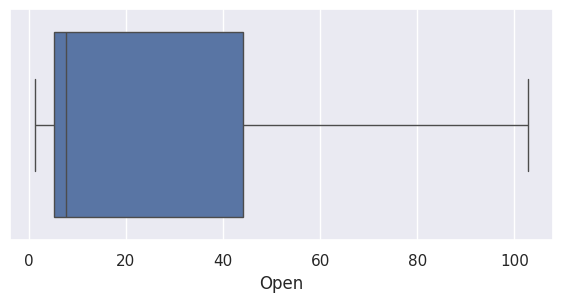

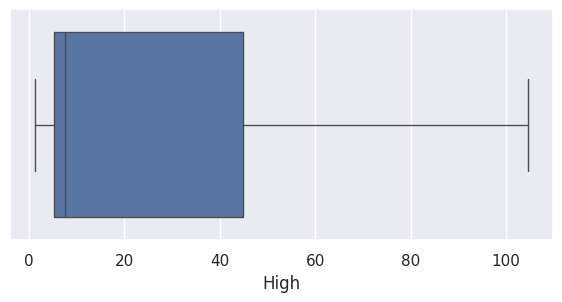

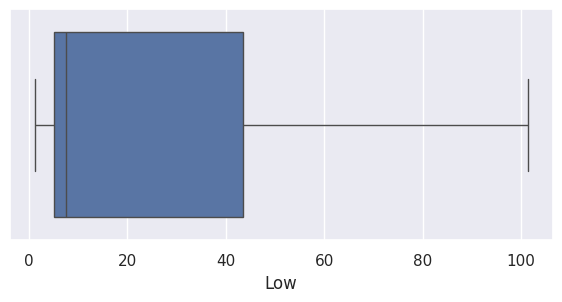

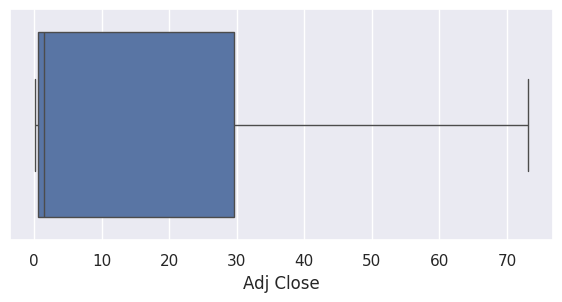

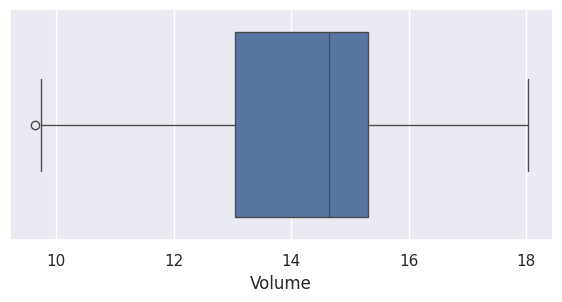

In [34]:
for col in numeric_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df_temp[col])
    plt.show()

In [36]:
for col in numeric_cols:
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_temp[col] < lower) | (df_temp[col] > upper)).sum()
    summary[col] = count
    print(f"{col}: {count} possible outliers")

Open: 0 possible outliers
High: 0 possible outliers
Low: 0 possible outliers
Adj Close: 0 possible outliers
Volume: 1 possible outliers


That single lower-bound outlier will not cause any problems for the machine learning model.

* **Minimal Statistical Weight:** It represents just one isolated, exceptionally low-volume trading day (often caused by low liquidity or a market half-day) out of thousands of historical records. A single data point does not possess enough mathematical weight to skew the pattern recognition of your ML algorithms.


* **Transformation Success:** The logarithmic transformation already did the heavy lifting by smoothing the overall distribution and compressing the massive upper trading spikes that actually distort model training.


## Display the Summary of the DataFrame
`info()` function provides a concise summary of a DataFrame, displaying key details such as:
1. Data type of each column
2. RangeIndex (total number of rows)
3. List of columns
4. Count of non-null entries in each column
5. Overall memory usage of the DataFrame.

In [41]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14665 entries, 0 to 14664
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       14665 non-null  object 
 1   Open       14665 non-null  float64
 2   High       14665 non-null  float64
 3   Low        14665 non-null  float64
 4   Adj Close  14665 non-null  float64
 5   Volume     14665 non-null  float64
dtypes: float64(5), object(1)
memory usage: 687.6+ KB


## Display Descriptive Statistical Features of DataFrame
`.describe()` function gives a quick summary of the **numerical columns** in the DataFrame.

It shows the basic statistics like:
- Average
- Minimum
- Maximum
- Standard deviation

for the numbers in the table

In [40]:
df_temp.describe()

,Open,High,Low,Adj Close,Volume
count,14665.000000,14665.000000,14665.000000,14665.000000,14665.000000
mean,28.503384,28.866079,28.152412,18.382461,14.230210
std,33.610563,34.061387,33.193757,26.430038,1.389673
min,1.234375,1.250000,1.229167,0.106720,9.629116
25%,5.156250,5.208333,5.093750,0.566898,13.047642
50%,7.656250,7.703125,7.593750,1.489241,14.649984
75%,44.200001,44.950001,43.599998,29.573622,15.315647
max,102.765627,104.562502,101.359371,73.083707,18.031784


In [42]:
df_temp.head()

,Date,Open,High,Low,Adj Close,Volume
0,1962-01-02,1.604167,1.619792,1.588542,0.136957,12.002738
1,1962-01-03,1.604167,1.619792,1.588542,0.138291,11.957618
2,1962-01-04,1.656250,1.708333,1.656250,0.141849,12.780439
3,1962-01-05,1.661458,1.697917,1.656250,0.143183,12.002738
4,1962-01-08,1.677083,1.703125,1.666667,0.144072,12.225880
